<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-celeste/PS4_FormalismoLagrangiano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mecánica Celeste
## 2023-II
## Set de Problemas No 4: Formalismos Lagrangiano y Hamiltoniano


Juan manuel cardenas

<br><br>


____

Solucion de puntos: 3, 7, 8, 9

In [ ]:
# Instalacion de librerias
!pip install -q celluloid # animaciones

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from celluloid import Camera # animacion
from IPython.display import HTML # visualizar animacion
from scipy.integrate import odeint # integracion numerica
from astropy import constants as ctes # constantes
from mpl_toolkits.mplot3d import Axes3D # superficies 3d

sp.init_printing(use_latex=True) # latex printing

### **3. Péndulo en soporte rotante.**
Un péndulo de longitud $l$ y masa $m$ se encuentra fijado a un soporte de masa despreciable que gira en un circulo de radio $a$ en un plano vertical, con velocidad angular constante $\omega$. Encuentre las ecuaciones de movimiento del sistema, utilizando el formalismo Lagrangiano. Solucione numéricamente y grafique (simule) el movimiento del péndulo.



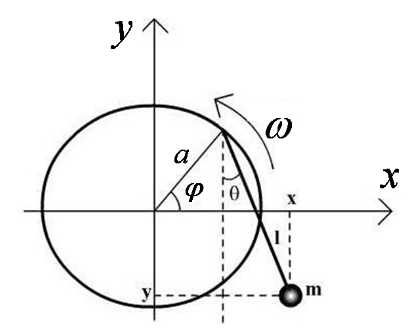


#### **Deduccion** de la ecuacion de movimiento del pendulo sobre soporte rotante:
<br>

<p align="center">
<img src= https://i.postimg.cc/RC2GJ72c/pendulo-rotante.jpg width="700">
</p>


A continuacion se realizó este mismo proceso simbolicamente mediante sympy:

In [ ]:
# definicion de variables simbolicas
a, l, m, g, w, t= sp.symbols('a l m g w t')

# variable generalizada y sus derivadas
q = sp.Function('θ')(t)
dq = sp.diff(q, t)
ddq = sp.diff(dq, t)

# reglas de transformacion
x_r = a*sp.cos(w*t) + l*sp.sin(q)
y_r = a*sp.sin(w*t) - l*sp.cos(q)

r = [x_r, y_r] # posicion
dr = np.array([sp.diff(r_i, t) for r_i in r]) # velocidad

# funcion cinetica
T = sp.simplify( m*sum(dr**2)/2 )

# funcion potencial
U = m*g*y_r

# Lagrangiano
L = T - U

# derivadas para las ecs euler-lagrange
dLdq = sp.diff(L, q)
dLddq = sp.diff(L, dq)
dt_dLddq = sp.diff(dLddq, t)

# ecs euler lagrange
ecs_EL = sp.Eq( sp.simplify(dLdq - dt_dLddq), 0)
accel = sp.solve(ecs_EL, ddq)[0] # despejando aceleracion

# pasando la aceleracion de simbolico a numerico + linealizando (para integracion numerica)
params = (t,a,l,g,w,q)
acc = sp.lambdify(params, accel)
vel = sp.lambdify(dq , dq)

Integracion numerica mediante Odeint

In [ ]:
# funcion para odeint
def dSdt(S, t, a, l, g, w):
  θ, dθ = S                 # [θ, w]

  return[vel(dθ),           # vel
         acc(t,a,l,g,w,θ)]  # accel


In [ ]:
# Parametros de la solucion particular (en el SI)
a = 1
l = 2
g_val = ctes.g0.value # [m/s^2]
w = 1

# ICS [θ, dθ]
ics = [0.7, 0]

# tiempo de integracion
ts = np.linspace(0, 50, 1000)

# solucion numerica
ans = odeint(dSdt, y0 = ics, t=ts, args=(a, l, g_val, w) )

In [ ]:
# Volviendo al sistema cartesiano para graficar
def gen_2_cartesian(θ, l, w, a, t):

  return ( a*np.cos(w*t), a*np.sin(w*t), # pivote
           a*np.cos(w*t) + l*np.sin(θ),  a*np.sin(w*t) - l*np.cos(θ)) # masa


x_p, y_p, x_m, y_m = gen_2_cartesian(ans[:,0], l, w, a, ts)

Animacion del pendulo rotante

In [ ]:
# Creacion de la figura
fig = plt.figure(figsize=(6,4))
cam = Camera(fig)

plt.title("Pendulo en soporte rotante: Solucion por ecuaciones de Euler-Lagrange")
plt.axis("equal")
plt.grid()
ntrazo = 5 # tamaño del trazo

for i in range(len(ts)):

  plt.plot([0], [0], 'ko') # origen
  plt.plot(x_p[i], y_p[i], 'ko') # pivote
  plt.plot(x_m[i], y_m[i], 'bo') # masa
  plt.plot([0, x_p[i]], [0, y_p[i]], 'k-') # varilla1
  plt.plot([x_p[i], x_m[i]], [y_p[i], y_m[i]], 'k-') # varilla2

  plt.plot(x_p[i-ntrazo*5:i], y_p[i-ntrazo*5:i], '-k', alpha=0.5) # trazo1
  plt.plot(x_m[i-ntrazo:i], y_m[i-ntrazo:i], '-b', alpha=0.5) # trazo2

  cam.snap() # captura frame

plt.close()

In [ ]:
# animacion
anim = cam.animate(interval=60)  # 60 ms de espera por frame
HTML(anim.to_html5_video())

###  **7. Partícula deslizándose sobre un alambre parabólico.**
Una partícula de masa $m$ se desliza bajo la acción de la gravedad y sin fricción sobre un alambre con forma de parábola.

**a.** Demuestre que el Hamiltoniano de este sistema se escribe como

\begin{equation}
  H(x,p) = \frac{p^2}{2m(1+x^2)} + \frac{mg}{2}x^2
\end{equation}


**Demostracion:**

<p align="center">
<img src= https://i.postimg.cc/fyrLJ2k9/hamilton-parabola.jpg width="900">
</p>

<br>

**b.** Grafique e interprete los contornos de nivel para este Hamiltoniano.



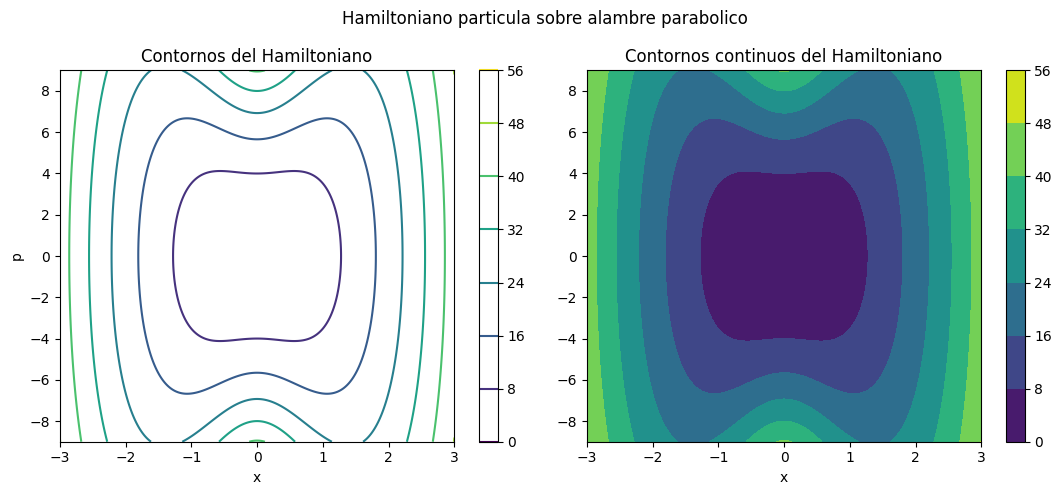

In [ ]:
# hamiltoniano del problema
def H_parabol(p, x, g, m):
  return p**2/(2*m*(1+x**2)) + m*g*x**2/2

m_val = 1 # masa

# plano xy
x_vals = np.linspace(-3, 3, 400)
p_vals = np.linspace(-9, 9, 400)
X, Y = np.meshgrid(x_vals, p_vals)
H_vals = H_parabol(Y, X, g_val, m_val) # hamiltoniano


# graficas de contornos
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11,5))
fig.suptitle('Hamiltoniano particula sobre alambre parabolico')

# Mapa de contornos 1:
ax[0].set_title('Contornos del Hamiltoniano')
ax[0].set_xlabel('x')
ax[0].set_ylabel('p')
contour1 = ax[0].contour(X, Y, H_vals, cmap='viridis') # contorno1
plt.colorbar(contour1, ax=ax[0]) # barra de color 1


# Mapa de contornos 2:
ax[1].set_title('Contornos continuos del Hamiltoniano')
ax[1].set_xlabel('x')
contour2 = ax[1].contourf(X, Y, H_vals, cmap='viridis') # contorno2
plt.colorbar(contour2, ax=ax[1])  # barra de color 2

plt.tight_layout()
plt.show()

Supongamos una "particula" que en este espacio de fase este situada uno de los contornos (puede ser alguno de los mas internos para visualizar) donde $x$ sea maximo y $p=0$, que sería el caso en el que la particula estuviese en el maximo derecho que alcanza sobre la parabola donde su velocidad es cero. Como el Hamiltoniano aumenta alejandose del origen, el "movimiento" que describirá sobre los contornos será en direccion perpendicular al gradiente, y hacia la derecha de este; entonces se dirigirá hacia abajo, disminuyendo x y aumentando negativamente el momento (que seria cuando la particula luego de estar en su maximo derecho, se devuelve sobre la parabola). <br>

Cuando la particula llega cerca al origen de la parabola, debido a la forma de la misma, el cambio en x va a ser menor que en el resto de la parabola, por lo que la magnitud del momento disminuirá, por eso los contornos son "achatados" cerca cuando x se aproxima al origen. luego de esta disminución de la magnitud del momento, la particula se seguirá desplazando a la parte izquierda de la parabola, por lo que la magnitud de su momento volverá a aumentar hasta que vuelve a disminuir casi a $0$ al llegar al limite izquierdo de la parabola, en ese punto se repite el proceso, pero en dirección contraria, aumentando x, de modo que el momento aumentará positivamente.
<br><br>

<br>

### **8. El Hamiltoniano de Hénon-Heiles**
En 1964, M. Hénon y C.Heiles estudiaban el movimiento de las estrellas alrededor del centro galáctico tratando de encontrar una tercera constante de movimiento a parte del momentum angular y la energía. Esto les llevo a proponer un potencial idealizado que restringía su acción solo al plano x, y. Este potencial se caracteriza por poseer dos términos cúbicos que involucran a las variables x, y haciendo a las ecuaciones de movimiento resultantes no lineales y acopladas. El Hamiltoniano asociado es el Hamiltoniano de Hénon-Heiles que en coordenadas cartesianas se escribe como

\begin{equation}
 H = \frac{p_x^2}{2m} + \frac{p_y^2}{2m} + \frac{1}{2}(x^2+y^2) + x^2y - \frac{1}{3}y^3
\end{equation}

**a.** ¿El Hamiltoniano de Hénon-Heiles coincide con la energía?<br>

> **Simetrias en Hamiltoniano**: una funcion $f$ con derivada total:
> $$ \frac{\mathrm{d}f}{\mathrm{d} t} = \left \{ f, H\right \} - \frac{∂f}{∂t} $$
> Es una cuadratura del espacio de fase siempre que cumpla las condiciones:
> * $\frac{∂f}{∂ t}=0$
> * $\left \{ f, H\right \} = \left \{ f, H\right \} = \frac{∂f}{∂q} \frac{∂H}{∂p}-\frac{∂f}{∂p} \frac{∂H}{∂q} = 0$
>
> En este caso el Hamiltoniano Hénon-Heiles no depende explicitamente del tiempo, y trivialmente $\left \{ H, H\right \}=0$, por lo que es una cuadratura del sistema.

> Ademas, los primeros 2 terminos del Hamiltoniano tienen la forma de la energia cinetica en el plano: $T =\frac{p_x^2}{2m} + \frac{p_y^2}{2m}$

> Mientras que el potencial es solo dependiente de las coordenadas generalizadas(las cartesianas en este caso), y repesentan la primera parte el potencial de un osilador armonico $\frac{1}{2}(x^2+y^2)$ mientras que la segunda es un potencial no armonico $x^2y - \frac{1}{3}y^3$ que tambien solo depende de las coordenadas generalizadas. por lo que este potencial es conservativo y se puede afirmar:
$$H = L + U $$
<br>

**b.** Deduzca las ecuaciones Hamiltonianas de movimiento para una masa m sometida a este potencial. Tenga en cuenta que $p_x = m\dot{x}$ y $p_y = m\dot{y}$.<br>

>**Ecuaciones de Hamilton**:
$$\left\{ \dot{p_j}= -\frac{∂H}{∂q_j} \right\}_M \quad \wedge \quad \left\{ \dot{q_j}=  \frac{∂H}{∂p_j} \right\}_M$$
>
> Para los **momentos**: <br>
> $\dot{p}_x= m\ddot{x} =-\frac{∂H}{∂q_j} = -x-2xy $ <br>
> $\dot{p}_y= m\ddot{y} =-\frac{∂H}{∂q_j} = -y -x^2 +y^2 $ <br>
>
> Para las **coordenadas**: <br>
> $\dot{x}= \frac{∂H}{∂p_x} = p_x/m = \dot{x}$ <br>
> $\dot{y}= \frac{∂H}{∂p_y} = p_y/m = \dot{y}$ <br>


A continuacion se definen el hamiltoniano simbolicamente, se obtienen las ecuaciones canonicas de hamilton y se integra numericamente mediante los dos metodos que se definienen como funciones: Euler y Leap-Frog


In [ ]:
# parametros simbolicos
m, x, y, px, py, H = sp.symbols('m x y p_x p_y H')
q = [x, y]; p = [px, py]

# hamiltoniano simbolico
HHH = px**2/(2*m) + py**2/(2*m) + (x**2 + y**2)/2 + y*x**2 - y**3/3


# condiciones iniciales adecuadas: E. Woollett (2015)
# (E = 0.1, y0 = 0.095, py0 = 0.096)
sustitucion = {m:1, x:0, y:0.095, py:0.096, H:0.1 }
PX = sp.solve((HHH-H).subs(sustitucion), px) # encontrando px0(tiene 2 soluciones)

# agrupando condiciones iniciales (x,y,px,py)
ICS = [0, 0.095 , PX[1], 0.096]

In [ ]:
# Pasando simbolico a numerico
params = (m, x, y, px, py)
Hamiltonian = sp.lambdify(params, HHH)

Definicion del sistema de la ecuaciones de hamilton, y los metodos de Euler y Leap-Frog

In [ ]:
def sistema_hamilton(x, y, px, py):
  dx  = px/m
  dy  = py/m
  dpx = (-x - 2*x*y)
  dpy = (-y - x**2 + y**2)
  return  dx, dy, dpx, dpy


def Euler_metod(T_total, h, sistema_hamilton, ICS):

  Nsteps = int(T_total/h)

  # soluciones (+1 = +ICS)
  x = np.zeros(Nsteps + 1)
  y = np.zeros(Nsteps + 1)
  px = np.zeros(Nsteps + 1)
  py = np.zeros(Nsteps + 1)

  x[0], y[0], px[0], py[0] = ICS

  for i in range(Nsteps): # t = 100, h=2, nstep=50, -1 ics

    dx, dy, dpx, dpy = sistema_hamilton(x[i], y[i], px[i], py[i])

    x[i+1] = x[i] + h*dx # ecs metodo euler
    y[i+1] = y[i] + h*dy
    px[i+1] = px[i] + h*dpx
    py[i+1] = py[i] + h*dpy

  return x, y, px, py



def LeapFrog_metod(T_total, h, sistema_hamilton, ICS):

  Nsteps = int(T_total/h)

  # soluciones (+1 = +ICS)
  x = np.zeros(Nsteps + 1)
  y = np.zeros(Nsteps + 1)
  px = np.zeros(Nsteps + 1) # velocidad * m
  py = np.zeros(Nsteps + 1)

  x[0], y[0], px[0], py[0] = ICS # pos ini

  for i in range(Nsteps):

    # kick (vel medi)
    dx, dy, dpx, dpy = sistema_hamilton(x[i], y[i], px[i], py[i])
    vx_half = dx + 0.5*h* dpx/m
    vy_half = dy + 0.5*h* dpy/m

    # drift (pos next)
    x[i+1] = x[i] + h*vx_half
    y[i+1] = y[i] + h*vy_half

    # kick (vel next)
    dx, dy, dpx_new, dpy_new = sistema_hamilton(x[i+1], y[i+1], px[i], py[i])
    px[i+1] = vx_half + h*dpx_new/m
    py[i+1] = vy_half + h*dpy_new/m


  return x, y, px*m, py*m

In [ ]:
# fijando parametros para solucion particular
m = 1         # masa
h = 0.001     # tamaño de paso de integracion
T_total = 100 # tiempo total
Nsteps = int(T_total/h)   # numero de pasos
ts = np.linspace(0, T_total, Nsteps+1) # tiempo de integracion

**c.** Para un par de condiciones iniciales apropiadas (fije un valor de la energía y encuentre valores de las variables generalizadas que la satisfagan) integre numéricamente las ecuaciones de movimiento usando el método de Euler y el integrador simpléctico Leap-Frog (Consultar). Grafique el comportamiento de la energía como función del tiempo ¿Es la energía una cantidad conservada con ambos esquemas?<br>






In [ ]:
# evaluando metodo euler
x_e, y_e, px_e, py_e = Euler_metod(T_total, h, sistema_hamilton, ICS)

E_euler = Hamiltonian(m, x_e, y_e, px_e, py_e) # energia

In [ ]:
# evaluando metodo Leap-frog
x_f, y_f, px_f, py_f = LeapFrog_metod(T_total, h, sistema_hamilton, ICS)

E_frog = Hamiltonian(m, x_f, y_f, px_f, py_f) # energia

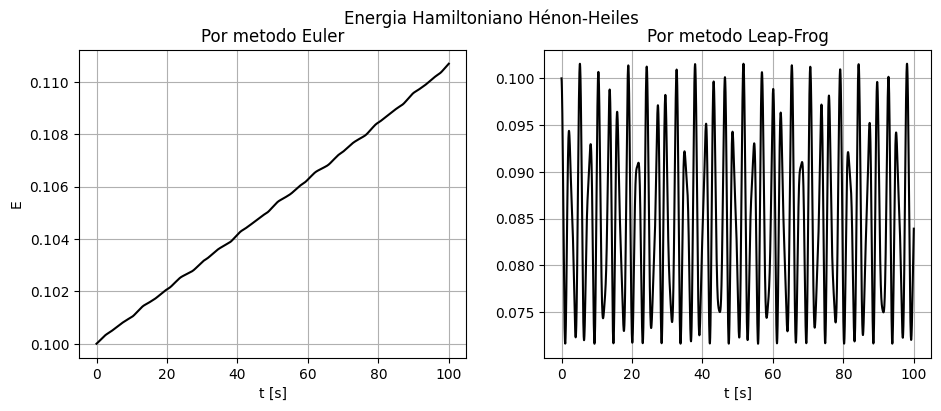

In [ ]:
# graficas conservacion energia

fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(11,4))
fig.suptitle('Energia Hamiltoniano Hénon-Heiles')

ax[0].set_title('Por metodo Euler')
ax[0].set_ylabel('E')
ax[0].set_xlabel('t [s]')
ax[0].plot(ts, E_euler, 'k')
ax[0].grid()

ax[1].set_title('Por metodo Leap-Frog')
ax[1].plot(ts, E_frog, 'k')
ax[1].set_xlabel('t [s]')
ax[1].grid()

> El metodo Euler es muy sensible al tamaño de paso de integracion ($h$), pues el metodo puede diverger mas rapido que el metodo Leap-frog teniendo el mismo tamaño de paso, como $h=0.1$, El metodo de Euler no conserva la energia, mientras incrementa $h$ el cambio en la energia es mayor, con un $h$ adecuado el cambio de la energia disminuye pero sigue existiendo.

> El metodo de Leap-Frog al ser simplectico si conserva la energia. independientemente del tamaño de paso, el metodo tiende a tener un cambio de energia oscilante acotado entre dos valores fijos, en parte se debe a que el potencial de Hénon-Heiles esta formado en parte por el potencial de un oscilador armonico.

<br>

**d.** Grafique la trayectoria en el espacio de configuración.

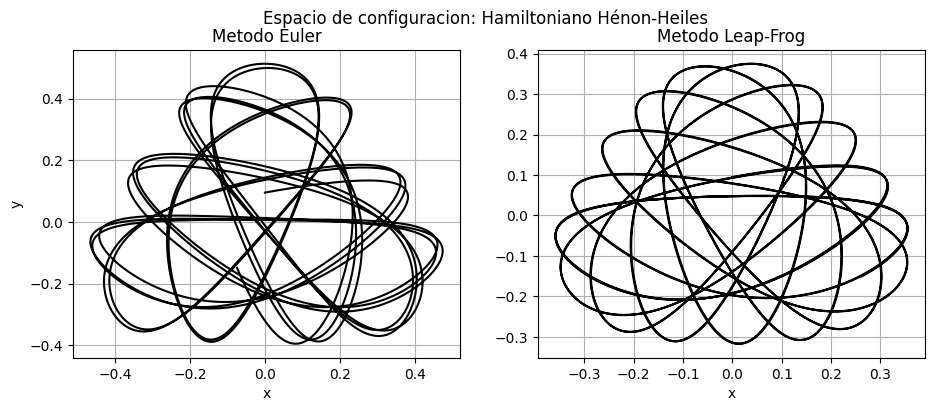

In [ ]:
# graficas espacio de configuracion

fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(11,4))
fig.suptitle('Espacio de configuracion: Hamiltoniano Hénon-Heiles')

ax[0].set_title('Metodo Euler')
ax[0].plot(x_e, y_e, 'k')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].grid()

ax[1].set_title('Metodo Leap-Frog')
ax[1].plot(x_f, y_f, 'k')
ax[1].set_xlabel('x')
ax[1].grid()





**e.** Grafique los contornos de nivel del potencial para distintos valores de la energía (E=$1/6$, $1/8$, $1/12$, $1/24$, $0,01$) y relacione los resultados con el inciso anterior.

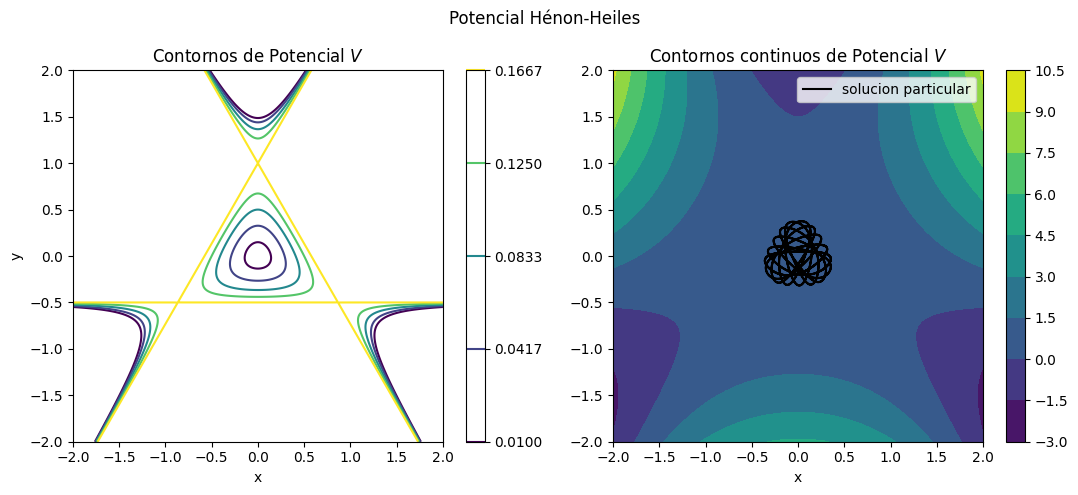

In [ ]:
# potencial HH
def V(x, y): return (x**2 + y**2)/2 + x**2*y - y**3/3

# plano xy
x_vals = np.linspace(-2, 2, 400)
y_vals = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x_vals, y_vals)
V_vals = V(X, Y) # potencial


# graficas de contornos
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11,5))
fig.suptitle('Potencial Hénon-Heiles')

# Mapa de contornos 1:
ax[0].set_title('Contornos de Potencial $V$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
niveles1 = np.sort([1/6, 1/8, 1/12, 1/24, 0.01]) # valores particulares de E
contour1 = ax[0].contour(X, Y, V_vals, levels=niveles1, cmap='viridis') # contorno1
plt.colorbar(contour1, ax=ax[0]) # barra de color 1


# Mapa de contornos 2:
ax[1].set_title('Contornos continuos de Potencial $V$')
ax[1].set_xlabel('x')
ax[1].plot(x_f, y_f, 'k', label='solucion particular')
contour2 = ax[1].contourf(X, Y, V_vals, cmap='viridis') # contorno2
plt.colorbar(contour2, ax=ax[1])  # barra de color 2
ax[1].legend()

plt.tight_layout()
plt.show()


Para una particula se quede confinada en la region cercana al origen, su energia debe ser menor a $1/6$, como en el caso particular que se eligió, con energia $0.1$ la particula se queda confinada en el valle de la region limitada por las rectas amarillas ($1/6$).
Los  3 puntos de interseccion de las rectas amarillas representan puntos de silla del potencial, mientras el origen es un minimo local.

El valor del potencial disminuye en las regiones donde los contornos son azul oscuro, como en las 2 regiones de las esquinas inferiores y el centro superior. mientras que aumenta fuera de las regiones limitadas por el contorno amarillo. sobre estas regiones el movmiento de las particulas no esta confinado y puede seguir las trayectorias asintoticas, siguiendo la regla que como el hamiltoniano es constante en el tiempo, la particula se mueve perpendicularmente al gradiente del hamiltoniano, en convencion de direccion derecha.

<br>

#### **Referencias**:

[1] E. Woollett (2015). Surfaces of Section for the Henon-Heiles Potential. recuperado de: https://home.csulb.edu/~woollett/example2.pdf

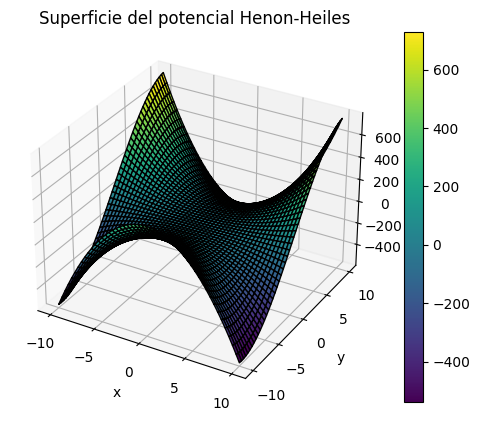

In [ ]:
# plano xy
x_vals = np.linspace(-10, 10, 400)
y_vals = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x_vals, y_vals)
V_vals = V(X, Y) # potencial

# grafica de la superficie del potencial HH
plt.figure()
ax = plt.axes(projection='3d')

plt.title('Superficie del potencial Henon-Heiles')
plt.xlabel('x')
plt.ylabel('y')

surf1 = ax.plot_surface(X, Y, V_vals, cmap='viridis', edgecolor='k')
plt.colorbar(surf1)
plt.show()

<br><br>

### **9. Mecánica generalizada.**

El término _mecánica generalizada_ se usa para designar una variación de la mecánica clásica en la que el Lagrangiano contiene derivadas temporales de $q_i$ más allá de primer orden. Problemas en los que $x = f(x,\dot{x},\ddot{x},t)$ han sido nombrados en inglés como _"jerky mechanics"_. Tales ecuaciones de movimiento tienen interesantes aplicaciones en teoría de caos (las cuales no trabajaremos).

Aplicando los métodos del cálculo de variaciones, muestre que si hay un lagrangiano de la forma $L(q_i,\dot{q}_i,\ddot{q}_i,t)$, y el principio de Hamilton permanece con la invarianza de $q_i$ y $\dot{q}_i$ en los extremos, entonces las ecuaciones de Euler-Lagrange correspondientes son:

\begin{equation}
\frac{d^2}{dt^2}\Big(\frac{\partial L}{\partial \ddot{q_i}}\Big) - \frac{d}{dt}\Big(\frac{\partial L}{\partial \dot{q_i}}\Big) + \frac{\partial L}{\partial q_i} = 0. \qquad i = 1,2,... ,n.
\end{equation}


**Demostracion:**

<p align="center">
<img src= https://i.postimg.cc/CMvq1nbN/deduccion-Euler-Lagrange.jpg width="1200">
</p>



Aplique el resultado al Lagrangiano:

\begin{equation}
L = -\frac{m}{2}q\ddot{q} - \frac{k}{2}q^2
\end{equation}

¿Reconoce las ecuaciones de movimiento encontradas?

<p align="center">
<img src= https://i.postimg.cc/PJcCzxsc/ejemplo-jerky.jpg width="700">
</p>

